## Computing log likelihoods of ground truth

In [1]:
from log_likelihood_ratio_test import log_likelihood_true, log_likelihood_tsfm, compute_llh_condition_ctx
from hmm import HMM, Mess3Proc
from model import HookedTransformerModel
from tqdm import tqdm
from scipy.special import logsumexp
import numpy as np
import pandas as pd
import os
import itertools
from collections import Counter
import torch as t
import matplotlib.pyplot as plt


In [2]:
proc = Mess3Proc()
num_seqs = 100000
seq_len = 4
sequences = proc.generate_data(num_seqs, seq_len)

In [69]:
sequences_tuple = [tuple(seq[0:4]) for seq in sequences.tolist()]
counter = Counter(sequences_tuple)


In [70]:
seq = list(itertools.product(range(3), repeat=sequences_tuple[0].__len__()))
log_likelihoods_true = log_likelihood_true(proc, np.array(seq), batch_mean=False, seq_mean=False, use_tqdm=True)

from hmm_proc_kldiv import compute_log_likelihood_forward_conditional

log_likelihoods_forward_conditional = compute_log_likelihood_forward_conditional(proc, np.array(seq), offset=-1, reduction=None, use_tqdm=True)
probs = np.exp(np.stack(log_likelihoods_true))
# 1. Prepare histogram data of sequences, sorted lex order (which is order of 'seq')
seq_strs = [''.join(map(str, tup)) for tup in seq]
hist_vals = [counter.get(tup, 0) for tup in seq]  # count for each sequence in lex order
hist_vals_arr = np.array(hist_vals)

Computing conditional log-likelihoods: 100%|██████████| 81/81 [00:00<00:00, 1041.24it/s]


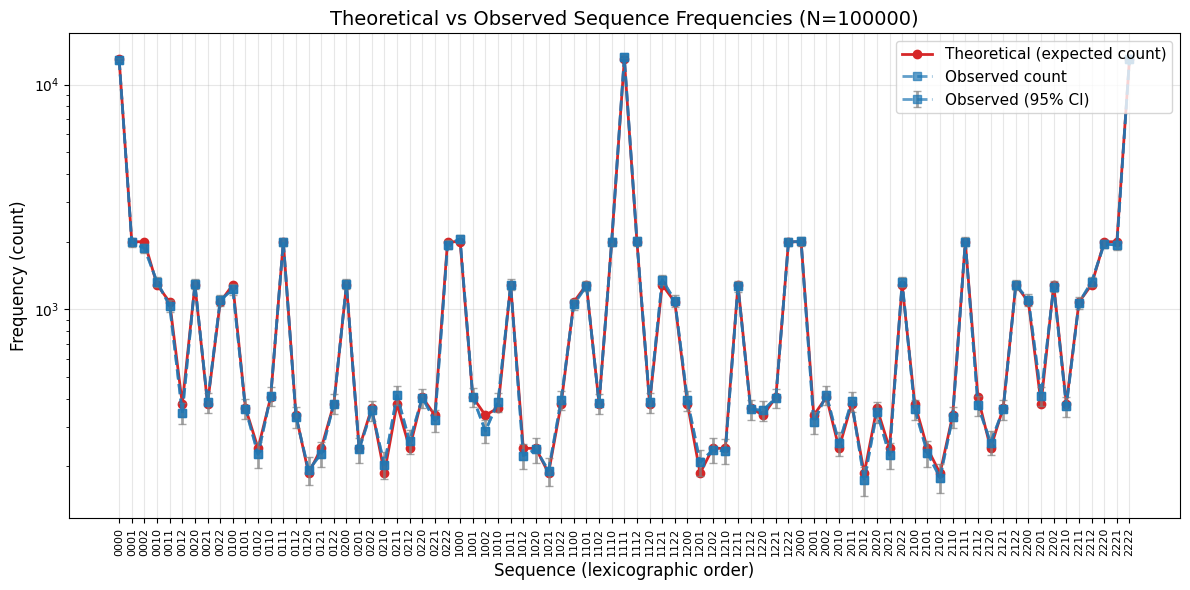

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))



# Scale theoretical probabilities to expected frequencies
theoretical_freq = probs * num_seqs
observed_freq = hist_vals_arr
probs_hat = hist_vals_arr / num_seqs
stderr = np.sqrt(probs_hat * (1 - probs_hat) / num_seqs) * num_seqs
ci_95 = 1.96 * stderr
# Plot
ax.plot(range(len(seq)), theoretical_freq, 'o-', color='tab:red',
        label='Theoretical (expected count)', linewidth=2, markersize=6)
ax.plot(range(len(seq)), observed_freq, 's--', color='tab:blue',
        label='Observed count', linewidth=2, markersize=6, alpha=0.7)
ax.errorbar(range(len(seq)), hist_vals_arr, yerr=ci_95,
            fmt='s--', color='tab:blue', ecolor='gray', capsize=3,
            label='Observed (95% CI)', linewidth=2, markersize=6, alpha=0.7,
zorder=2)


ax.set_xlabel('Sequence (lexicographic order)', fontsize=12)
ax.set_ylabel('Frequency (count)', fontsize=12)
ax.set_yscale('log')
ax.set_title(f'Theoretical vs Observed Sequence Frequencies (N={num_seqs})',
fontsize=14)
ax.set_xticks(range(len(seq)))
ax.set_xticklabels(seq_strs, rotation=90, fontsize=8)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Log likelihood ratios

In [46]:
# generate test sequences
proc = Mess3Proc()
test_sequences = proc.generate_data(20, 5000)

# Look for model instances
metadata_path = '/mnt/extraspace/clin/records/metadata.parquet'
df = pd.read_parquet(metadata_path)
df_completed = df[df['status'] == 'completed']
selected_locs = [462, 426, 450, 13, 546]
df_selected = df_completed.loc[selected_locs]
print(df_selected[['final_val_loss', 'param_count', 'n_ctx']])

     final_val_loss  param_count  n_ctx
462        0.798683       1168.0   15.0
426        0.800942       1128.0   10.0
450        0.804654       2352.0    8.0
13         0.820299       4320.0    4.0
546        0.816131        824.0    4.0


In [51]:
# Define and load the model
model_dir_path = df.loc[462]['run_dir']
def load_model(model_dir_path, device='cpu'):
    model = HookedTransformerModel(os.path.join(model_dir_path, 'config.yaml'))
    model.load_state_dict(t.load(os.path.join(model_dir_path, 'final_model_mess3.pt'), map_location=device))
    model.eval()
    return model
model = load_model(model_dir_path)

In [52]:
# compare the llr
llh_full_seq, llh_prefix_seq, log_prob_tsfm = compute_llh_condition_ctx(proc, model, test_sequences, device='cpu')

Computing true log-likelihood:   0%|          | 0/20 [00:00<?, ?it/s]

Computing true log-likelihood: 100%|██████████| 20/20 [00:00<00:00, 606.64it/s]


Moving model to device:  cpu


In [53]:
cond_log_prob_tsfm = log_prob_tsfm.sum(axis=1)
cond_log_prob_true = np.array(llh_full_seq) - np.array(llh_prefix_seq)

In [54]:
print(cond_log_prob_true - cond_log_prob_tsfm)
print(f"Mean Accumulated LLR: {np.mean(cond_log_prob_true - cond_log_prob_tsfm)}")

[ 3.76024318  5.82184286 -0.53904533  3.37884638  3.52110694 11.16623078
  2.92136736  3.86658775  2.2052016   6.53614134  6.72948716  7.36153718
  0.04841526  6.86904974 -0.49201675  0.98257376  9.02025935  1.04299429
 -2.31036254  9.53088336]
Mean Accumulated LLR: 4.071067182774755
